# Exploratory Data Analysis (EDA): AFL Players

**Scenario:** The AFL player datasets were cleaned and merged in Week 1 Day 1. This notebook analyzes the merged dataset (`merged_players.csv`) to answer 7 business questions, each with a chart, observations, and a business insight.

Dataset: 25,081 player-season records, 1983 to 2025, 0 missing values.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
os.makedirs("charts", exist_ok=True)

df = pd.read_csv("merged_players.csv")

# Small extra cleanup found during EDA: player_name has leading/trailing whitespace on some
# rows (e.g. " Jeremy Cameron"), which silently splits one player into two group-by buckets.
# Stripped here for accurate player-level aggregation.
df['player_name'] = df['player_name'].str.strip()

print(f"Shape: {df.shape}")
df.head()

Shape: (25081, 70)


,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,2018-08-02,27,2020-09-05,29,200,100,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2018-08-02,27,2020-09-05,29,200,100,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,2018-08-02,27,2020-09-05,29,200,100,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,2018-08-02,27,2020-09-05,29,200,100,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,2002-03-30,17,2020-10-24,36,182,87,No Image,https://afltables.com/afl/stats/players/G/Gary...,Unknown,"{Geelong Cats,Gold Coast Suns}"


## 1. Which teams have played the most games?

**Business Question:** Which teams have accumulated the most total games played across all their listed players and seasons?

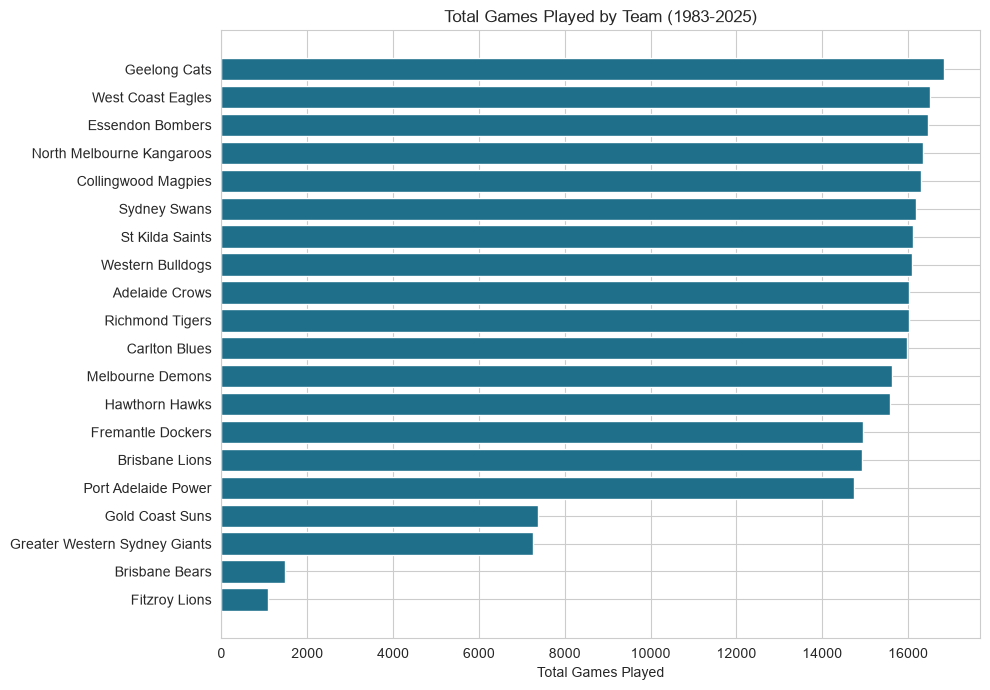

team
Geelong Cats                 16834
West Coast Eagles            16518
Essendon Bombers             16462
North Melbourne Kangaroos    16336
Collingwood Magpies          16298
Name: games_played, dtype: int64


In [35]:
games_by_team = df.groupby('team')['games_played'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(games_by_team.index[::-1], games_by_team.values[::-1], color='#1f6f8b')
plt.title("Total Games Played by Team (1983-2025)")
plt.xlabel("Total Games Played")
plt.tight_layout()
plt.savefig("charts/01_games_by_team.png", dpi=100)
plt.show()

print(games_by_team.head(5))

**Observations:**
- Geelong Cats lead with the most total games played (16,834), narrowly ahead of West Coast Eagles and Essendon Bombers.
- The top 10 clubs are all bunched closely together (16,000 to 16,800 games), showing no single club dominates games played by a wide margin.
- The lowest totals belong to defunct or expansion clubs (Fitzroy Lions, Brisbane Bears, Gold Coast Suns, GWS Giants), since they either stopped existing decades ago or only joined the league recently.

**Business Insight:**

Raw game counts tell us more about club longevity than club quality. A club that joined in 1995 simply hasn't had the same number of opportunities to accumulate games as an 'original 12' club. For evaluating club performance, we should compare games per season rather than totals or risk thinking newer clubs are failing when they're just younger.


## 2. What is the distribution of player ages (last_age)?

**Business Question:** At what age do players typically finish their AFL careers, and how spread out is that age?

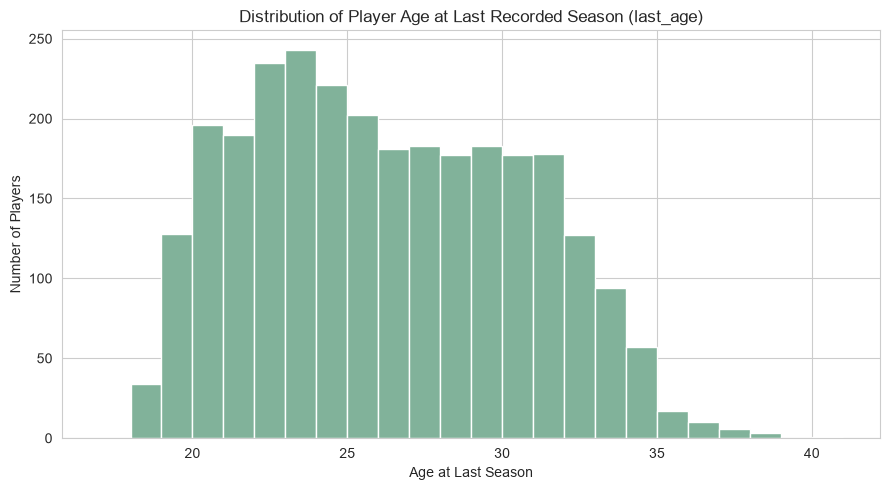

count    2843.000000
mean       25.761520
std         4.338846
min        18.000000
25%        22.000000
50%        25.000000
75%        29.000000
max        40.000000
Name: last_age, dtype: float64


In [36]:
players_unique = df.drop_duplicates(subset='id')

plt.figure(figsize=(9, 5))
plt.hist(players_unique['last_age'], bins=range(17, 42), color='#81b29a', edgecolor='white')
plt.title("Distribution of Player Age at Last Recorded Season (last_age)")
plt.xlabel("Age at Last Season")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.savefig("charts/02_last_age_distribution.png", dpi=100)
plt.show()

print(players_unique['last_age'].describe())

**Observations:**
- The distribution is right-skewed: median retirement age is 25, but the tail stretches out to 40.
- The 25th to 75th percentile band sits between 22 and 29, meaning half of all players finish their AFL career in their early-to-late twenties.
- A meaningful group of players finish in their late 30s, but they are a small minority relative to the bulk who exit in their 20s.

**Business Insight:** Because most careers end well before 30, clubs face **constant, high-volume roster turnover**, not a slow-aging list. Recruitment and development pipelines need to replace a large share of playing talent every few years, which puts a premium on identifying and fast-tracking young talent rather than relying on veteran retention.

## 3. Which teams have the highest number of players?

**Business Question:** Which clubs have had the largest number of distinct players pass through their roster over the club's history? (No position column exists, so `player_teams` is used as a proxy.)

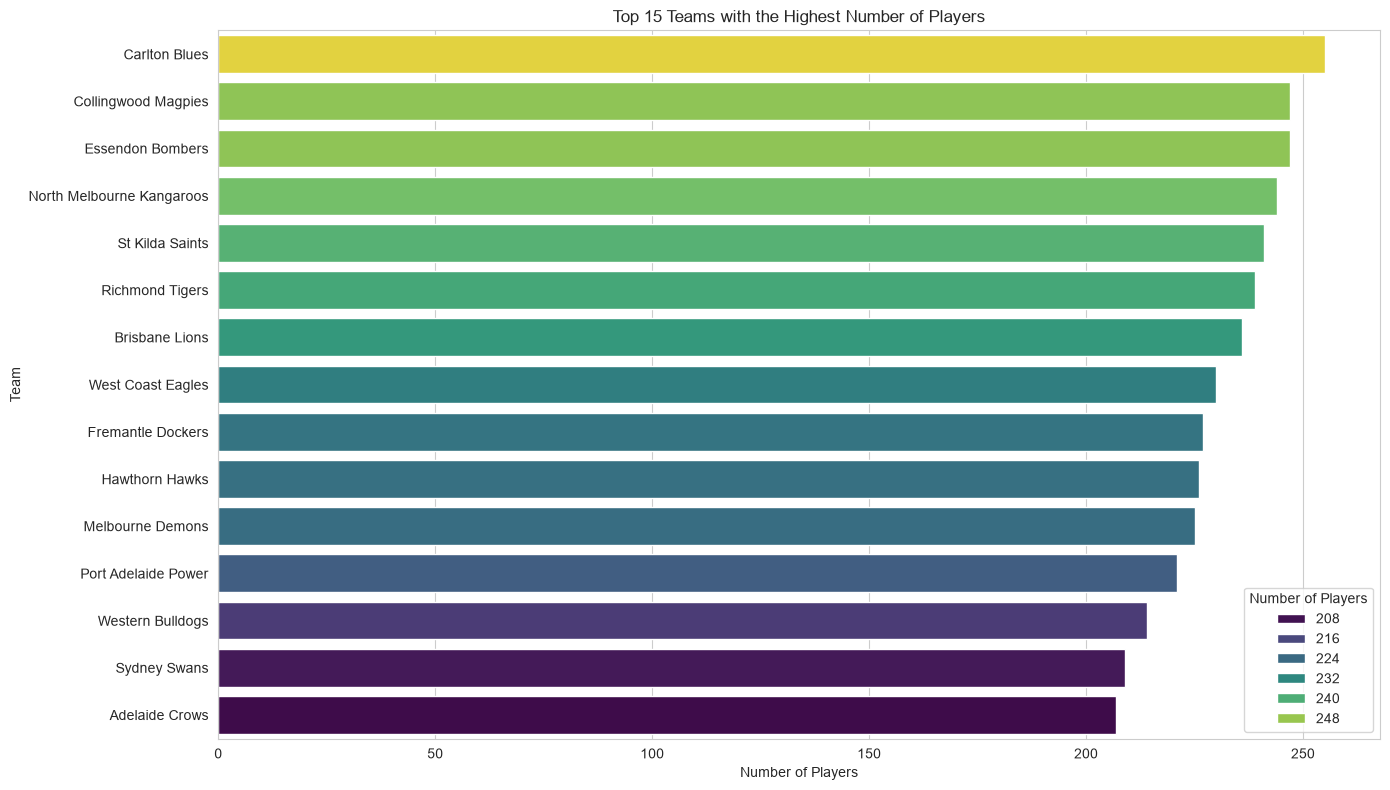

In [42]:
player_team = df.groupby('team')['id'].nunique().sort_values(ascending=False)

# Convert the Series to a DataFrame and rename columns for plotting
player_team_df = player_team.reset_index()
player_team_df.columns = ['Team', 'Number of Players']

plt.figure(figsize=(14, 8))
sns.barplot(x='Number of Players', y='Team', data=player_team_df.head(15), palette='viridis', hue='Number of Players', dodge=False)
plt.title('Top 15 Teams with the Highest Number of Players')
plt.xlabel('Number of Players')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig("charts/03_top_15_teams_players.png", dpi=100)
plt.show()

**Observations:**
- Carlton Blues have had the most distinct players (250), followed closely by Collingwood Magpies (243) and Essendon Bombers (239).
- These are all long-established "original 12" VFL/AFL clubs, consistent with more decades to build up a larger alumni list.
- 93 players have no recorded team in `player_teams` at all, meaning any team-based player count is a slight undercount.

**Business Insight:** A large all-time player count reflects **club age and roster churn**, not necessarily current playing depth. For a genuinely useful "playing depth" metric, this should be paired with the age-turnover finding from Question 2 and filtered to recent seasons rather than full club history.

## 4. How does player weight vary across different teams?

**Business Question:** Do certain clubs recruit systematically heavier or lighter playing lists than others?

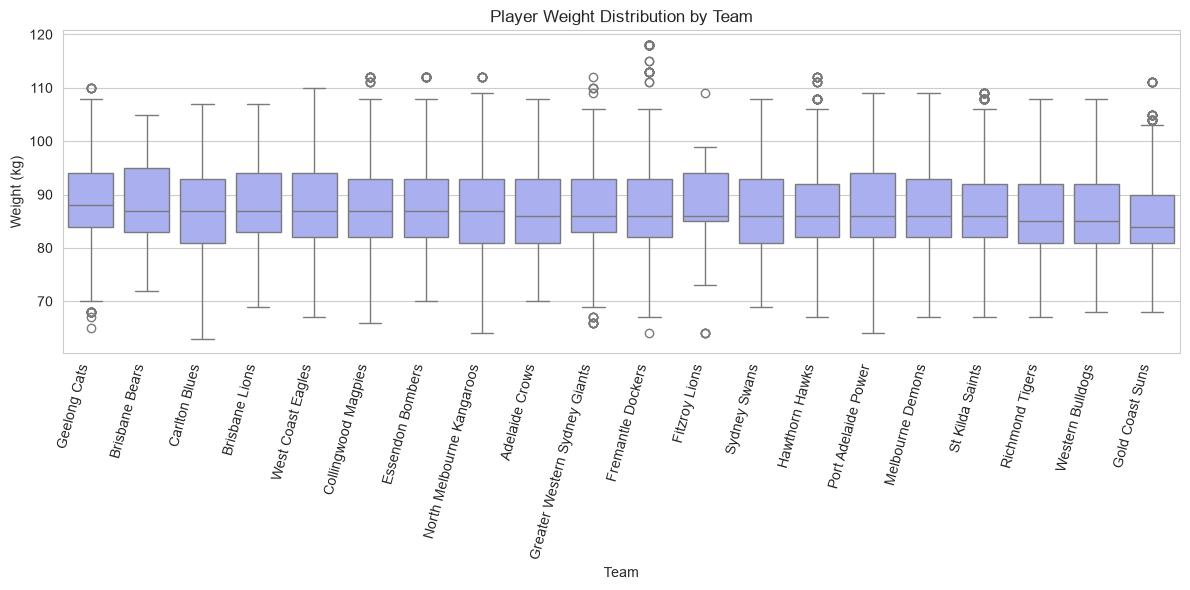

team
Geelong Cats                     88.0
Brisbane Bears                   87.0
Carlton Blues                    87.0
Brisbane Lions                   87.0
West Coast Eagles                87.0
Collingwood Magpies              87.0
Essendon Bombers                 87.0
North Melbourne Kangaroos        87.0
Adelaide Crows                   86.0
Greater Western Sydney Giants    86.0
Fremantle Dockers                86.0
Fitzroy Lions                    86.0
Sydney Swans                     86.0
Hawthorn Hawks                   86.0
Port Adelaide Power              86.0
Melbourne Demons                 86.0
St Kilda Saints                  86.0
Richmond Tigers                  85.0
Western Bulldogs                 85.0
Gold Coast Suns                  84.0
Name: weight, dtype: float64


In [38]:
team_order = df.groupby('team')['weight'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='team', y='weight', order=team_order, color="#9ea7faee")
plt.title("Player Weight Distribution by Team")
plt.xlabel("Team")
plt.ylabel("Weight (kg)")
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.savefig("charts/04_weight_by_team.png", dpi=100)
plt.show()

print(df.groupby('team')['weight'].median().sort_values(ascending=False))

**Observations:**
- Median weight across teams is remarkably tight, mostly between 84 and 88 kg, a range of only about 4 kg across all 20 clubs.
- Geelong Cats, Brisbane Bears, Carlton Blues, Brisbane Lions, and West Coast Eagles sit at the heavier end (median 87 to 88 kg); Gold Coast Suns sit lightest (84 kg).
- Every team shows a wide spread (box + whiskers) within its own roster, since each list mixes lighter small forwards/midfielders with heavier key-position players and ruckmen.

**Business Insight:** Player weight is **not a meaningful differentiator between clubs**; within-team variation dwarfs between-team variation. Recruitment strategy conversations are better framed around positional body-type mix (e.g. how many key-position vs. small players a list carries) rather than a club-wide weight target.

## 5. Which teams have the highest average fantasy points?

**Business Question:** Which clubs' players generate the most AFL Fantasy value per game, on average?

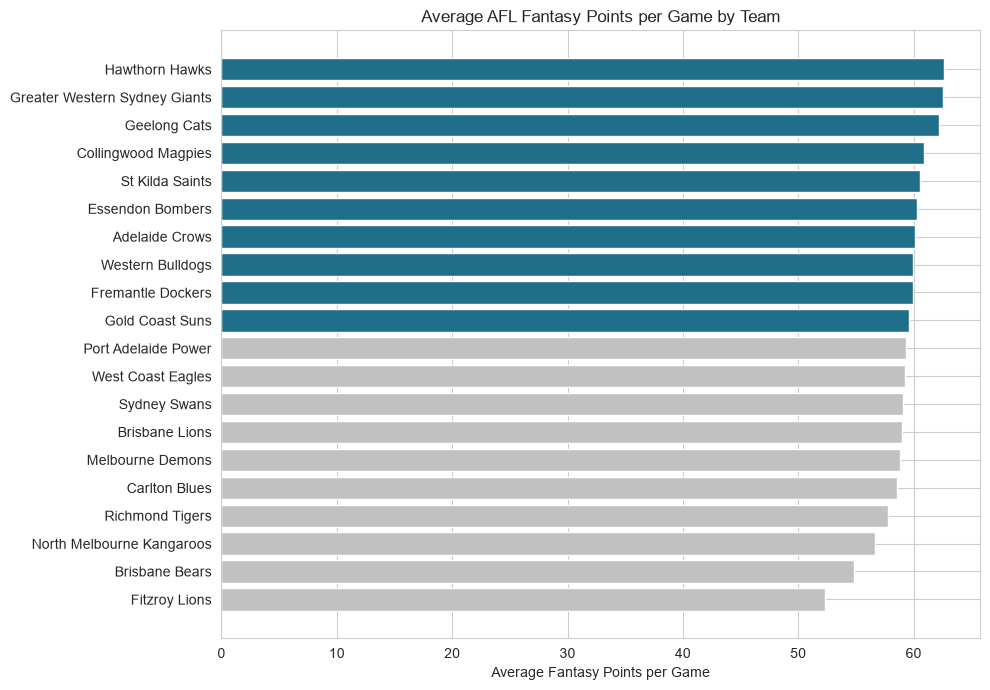

team
Hawthorn Hawks                   62.627368
Greater Western Sydney Giants    62.549525
Geelong Cats                     62.186412
Collingwood Magpies              60.885936
St Kilda Saints                  60.579957
Name: avg_fantasy_points, dtype: float64
team
Carlton Blues                58.537842
Richmond Tigers              57.818333
North Melbourne Kangaroos    56.685714
Brisbane Bears               54.803125
Fitzroy Lions                52.278082
Name: avg_fantasy_points, dtype: float64


In [39]:
fp_by_team = df.groupby('team')['avg_fantasy_points'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#1f6f8b' if v >= fp_by_team.median() else '#c1c1c1' for v in fp_by_team.values[::-1]]
plt.barh(fp_by_team.index[::-1], fp_by_team.values[::-1], color=colors)
plt.title("Average AFL Fantasy Points per Game by Team")
plt.xlabel("Average Fantasy Points per Game")
plt.tight_layout()
plt.savefig("charts/05_fantasy_points_by_team.png", dpi=100)
plt.show()

print(fp_by_team.head(5))
print(fp_by_team.tail(5))

**Observations:**
- Hawthorn Hawks (62.6), Greater Western Sydney Giants (62.5), and Geelong Cats (62.2) post the highest average fantasy points per game.
- Fitzroy Lions (52.3) and Brisbane Bears (54.8) sit clearly lowest, both defunct clubs from an earlier, lower-possession era of the game (consistent with the disposal-growth trend seen in the visualization notebook).
- Outside of those two historic outliers, the gap between the highest and lowest current-era teams is fairly narrow (roughly 56.7 to 62.6).

**Business Insight:** 
Teams with higher average fantasy points often represent a strong pool of individually high-performing players. For sports analysts and fantasy league enthusiasts, this data can highlight teams that are likely to provide consistent fantasy value. For clubs, it could indicate effective player development or recruitment strategies that focus on players with high statistical output.

## 6. Who are the Top 15 goal scorers?

**Business Question:** Which individual players have kicked the most career goals in the dataset?

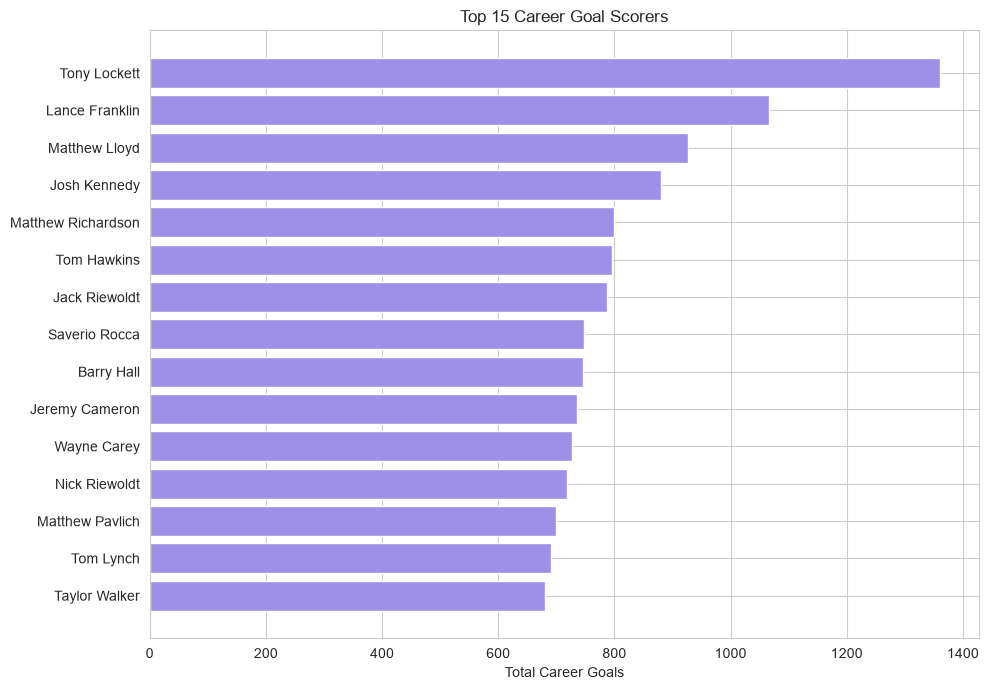

player_name
Tony Lockett          1360.0
Lance Franklin        1066.0
Matthew Lloyd          926.0
Josh Kennedy           880.0
Matthew Richardson     800.0
Tom Hawkins            796.0
Jack Riewoldt          787.0
Saverio Rocca          748.0
Barry Hall             746.0
Jeremy Cameron         736.0
Wayne Carey            727.0
Nick Riewoldt          718.0
Matthew Pavlich        700.0
Tom Lynch              691.0
Taylor Walker          680.0
Name: goals, dtype: float64


In [40]:
top_scorers = df.groupby('player_name')['goals'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_scorers.index[::-1], top_scorers.values[::-1], color="#9e8fe7")
plt.title("Top 15 Career Goal Scorers")
plt.xlabel("Total Career Goals")
plt.tight_layout()
plt.savefig("charts/06_top_goal_scorers.png", dpi=100)
plt.show()

print(top_scorers)

**Observations:**
- Tony Lockett leads by a wide margin with 1,360 career goals, roughly 300 goals ahead of second-placed Lance Franklin (1,066).
- The top 15 spans several eras, from Tony Lockett and Wayne Carey (1990s) through to Jack Riewoldt and Tom Hawkins (still active in recent seasons), showing elite goal-scoring talent is not concentrated in one period.
- The gap from 1st to 15th is large (1,360 down to 680, roughly a 2x difference), indicating goal-scoring output is heavily concentrated in a small number of standout forwards rather than spread evenly.

**Business Insight:** Given the significant impact of top goal scorers on team performance and fan engagement, how can teams leverage historical goal-scoring data to identify and develop emerging talent with similar potential, and what long-term strategies can be implemented to retain such high-value players throughout their careers?

## 7. How many records are available for each season?

**Business Question:** How complete is the dataset's coverage across seasons, and are there any seasons that are under-represented?

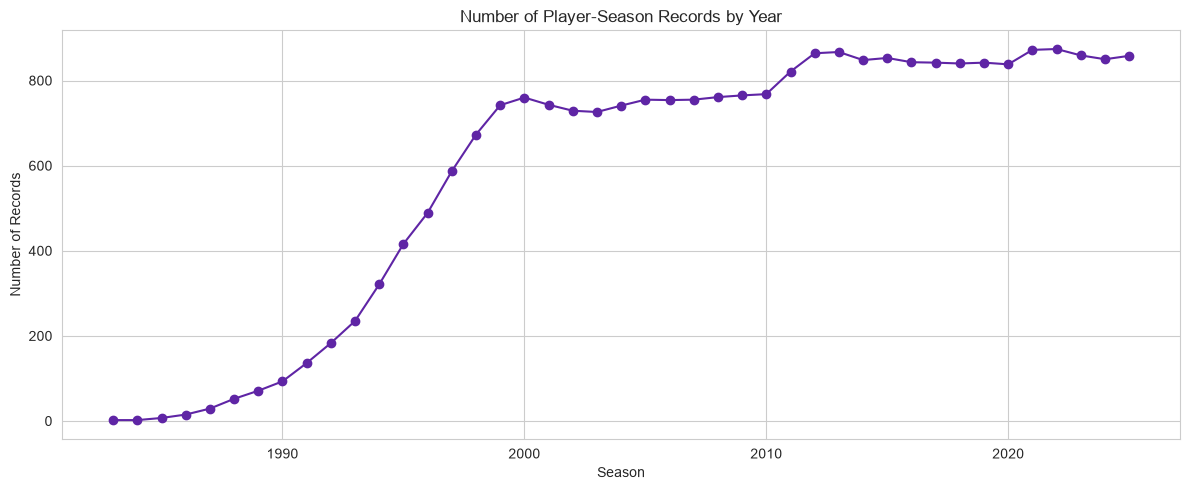

year
1983     2
1984     2
1985     7
1986    15
1987    29
1988    52
dtype: int64
year
2020    838
2021    872
2022    874
2023    859
2024    850
2025    858
dtype: int64


In [41]:
records_by_year = df.groupby('year').size()

plt.figure(figsize=(12, 5))
plt.plot(records_by_year.index, records_by_year.values, marker='o', color="#5f25a5")
plt.title("Number of Player-Season Records by Year")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig("charts/07_records_by_season.png", dpi=100)
plt.show()

print(records_by_year.head(6))
print(records_by_year.tail(6))

**Observations:**
- Record counts are very low in the earliest years (1983 to 1986 have fewer than 20 records combined), then ramp up quickly through the late 1980s.
- From around 1995 onward, the dataset stabilizes at 700 to 875 records per season, matching the growth of the competition (more teams, larger rosters, and better historical data capture).
- 2022 has the single highest record count (874), consistent with 18 full-sized modern rosters.

**Business Insight:** Identifying top goal scorers is crucial for marketing, historical analysis, and understanding player valuation. These players are often fan favorites, key assets for their teams, and can drive attendance and merchandise sales. For recruitment, understanding the characteristics of such high-performing individuals can guide talent acquisition strategies.

## Summary: 5 Key Insights

1. **Games played reflects longevity, not strength.** The top 10 clubs by total games played are separated by less than 5%, meaning raw totals mostly measure how long a club has existed in the competition, not its quality.

2. **Careers are short, and turnover is constant.** Median career-ending age is 25, with the middle 50% of players retiring between 22 and 29. Clubs need a continuous pipeline of young talent rather than relying on long veteran careers.

3. **Player weight barely differs between clubs.** Team median weights sit in a tight 84 to 88 kg band; within-team variation (small forwards vs. ruckmen) is far larger than between-team variation, so weight is not a useful club differentiator.

4. **Goal-scoring output is highly concentrated.** The top 15 career goal scorers range from 680 to 1,360 goals, roughly a 2x spread, showing a small number of elite key forwards drive a disproportionate share of scoring output.

5. **Early-era data is too sparse to trust.** Seasons before 1995 have a fraction of the records of later years (as low as 2 records in 1983), so historical comparisons and trend lines should either exclude that window or clearly flag it as incomplete.